# 04 — v2 Headline Evaluation

**FusionCore v2 — Phase Ph-v2.3**

The NASA Official Test Set is opened **exactly once** to evaluate the full
calibrated v2 stack. The headline numbers are the moment of truth for
deciding whether v2 supersedes v1 and v0 XGBoost.

### Calibrated outputs evaluated

1. **RUL point prediction** — Stage B PiNet RUL head, clipped to [0, 125]
2. **RUL intervals** — three nominal levels (95 %, 90 %, 80 %) via the
   conformal half-widths from Ph-v2.1
3. **Risk-band probabilities** — temperature-scaled via the T from Ph-v2.2
4. **Risk-band classification** — argmax of the (post-T) probabilities

### Comparison baselines

| System | RMSE | NASA | F₂_C | Critical recall |
|---|---|---|---|---|
| v0 XGBoost (operational baseline) | 14.85 | 4,336.3 | 0.9339 | ≈ 0.93 |
| v1 PiNet (Stage A — failed Ph-v1.4 gate) | 24.66 | 32,204 | 0.4735 | 0.42 |
| **v2 PiNet (Stage B + calibration)** | this notebook | this notebook | this notebook | this notebook |

### New v2 metrics beyond v1

- **Empirical interval coverage** at each α — does the true RUL fall within the prediction interval at the rate the nominal level promises?
- **Risk-band ECE** on the temperature-scaled probabilities
- **Risk-band Brier score** (Brier 1950)

### Iron Wall Protocol

Test set opened exactly once at this notebook. Stage B model frozen at
Ph-v2.0; conformal q frozen at Ph-v2.1; temperature T frozen at Ph-v2.2.
No retraining or re-tuning after Ph-v2.3 results are recorded.

### Outputs (under `v2/outputs/`)

| File | Purpose |
|---|---|
| `phase_v2_3_test_predictions.parquet` | Per-engine test predictions with calibrated outputs |
| `phase_v2_3_headline_metrics.json` | Pooled and per-subset metrics + interval coverage + ECE |
| `phase_v2_3_predicted_vs_actual_with_intervals.png` |
| `phase_v2_3_residuals.png` |
| `phase_v2_3_confusion.png` |
| `phase_v2_3_reliability_diagram_test.png` |
| `phase_v2_3_coverage_by_alpha.png` |

### References
- Brier, G. W. (1950). Verification of forecasts. *Monthly Weather Review* 78(1).
- Lei, J. *et al.* (2018). Distribution-free predictive inference. *JASA*.
- Guo, C. *et al.* (2017). On calibration. *ICML*.
- Saxena, A. *et al.* (2008). Damage propagation modeling. *PHM*.

## Cell 1 — Imports

In [1]:
# ============================================================================
# Cell 1 — Imports
# ============================================================================
import sys, os, json, warnings, time, pickle
from pathlib import Path
from typing import Dict, Tuple

import numpy as np
import pandas as pd
import joblib
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import (precision_recall_fscore_support, confusion_matrix,
                              mean_absolute_error)
warnings.filterwarnings("ignore")
print(f"Python : {sys.version.split()[0]}    PyTorch : {torch.__version__}")

Python : 3.13.13    PyTorch : 2.11.0


## Cell 2 — Palette

In [2]:
# ============================================================================
# Cell 2 — Palette
# ============================================================================
FC_DARK_BLUE  = "#0D1B2A"; FC_NAVY = "#1B3A5C"; FC_ORANGE = "#D96A1B"
FC_DEEP_RED   = "#9B1B30"; FC_STEEL = "#4A6274"; FC_CHARCOAL = "#2D2D2D"
FC_LIGHT_GREY = "#E8E8E8"
FC_PALETTE = [FC_DARK_BLUE, FC_ORANGE, FC_DEEP_RED, FC_STEEL, FC_NAVY]
plt.rcParams.update({
    "figure.figsize":(14,5), "figure.dpi":110, "savefig.dpi":300, "savefig.bbox":"tight",
    "font.family":"serif", "font.size":11,
    "axes.titlesize":13, "axes.titleweight":"bold", "axes.labelsize":11,
    "axes.edgecolor":FC_CHARCOAL, "axes.labelcolor":FC_CHARCOAL,
    "axes.spines.top":False, "axes.spines.right":False,
    "axes.prop_cycle":mpl.cycler(color=FC_PALETTE),
    "xtick.color":FC_CHARCOAL, "ytick.color":FC_CHARCOAL,
    "legend.fontsize":9, "legend.framealpha":0.9,
    "grid.color":FC_LIGHT_GREY, "grid.alpha":0.6, "grid.linestyle":":",
})
print("Palette configured.")

Palette configured.


In [3]:
# ============================================================================
# Cell 3 — Constants and Paths
# ============================================================================
PROJECT_ROOT = Path("/Users/michelemaestrini/Desktop/PiNet/FusionCore")
V0_OUT = PROJECT_ROOT / "v0" / "outputs"
V1_OUT = PROJECT_ROOT / "v1" / "outputs"
V2_OUT = PROJECT_ROOT / "v2" / "outputs"

W = 30; N_FEATURES = 89; N_PHYSICS_TOKENS = 11
TCN_HIDDEN = 64; TCN_KERNEL = 3; TCN_DILATIONS = [1,2,4,8,16]; TCN_DROPOUT = 0.25
EMBED_DIM = 128; PHYS_HIDDEN = 50; PHYS_OUT = 32; HEAD_HIDDEN = 64
N_RISK_CLASSES = 3; RUL_CAP = 125; BATCH_SIZE = 64
NASA_LATE_EXP = 10.0; NASA_EARLY_EXP = 13.0
HEALTHY_TH = 80; WARNING_TH = 30

# Comparison baselines
V0_RMSE        = 14.85
V0_NASA        = 4336.3
V0_F2_C        = 0.9339
V0_R_C         = 0.9363   # Actual recall from v0 phase5_four_quadrant_results.pkl
                          # quadrant_c["C2 Recall"]["XGBoost"] (replaces F2 proxy 0.9339).
V1A_RMSE       = 24.66
V1A_NASA       = 32204.3
V1A_F2_C       = 0.4735
V1A_R_C        = 0.4204

DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
print(f"Device : {DEVICE}")

Device : mps


---

## Part A — PiNet (re-defined inline) and Load Calibrated Stack

In [4]:
# ============================================================================
# Cell 4 — PiNet Architecture
# ============================================================================
class CausalConv1d(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation):
        super().__init__()
        self.left_pad = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(in_ch, out_ch, kernel_size, padding=0, dilation=dilation)
    def forward(self, x): return self.conv(F.pad(x, (self.left_pad, 0)))
class TemporalBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation, dropout):
        super().__init__()
        self.conv1 = CausalConv1d(in_ch, out_ch, kernel_size, dilation)
        self.norm1 = nn.LayerNorm(out_ch)
        self.conv2 = CausalConv1d(out_ch, out_ch, kernel_size, dilation)
        self.norm2 = nn.LayerNorm(out_ch)
        self.dropout = nn.Dropout(dropout)
        self.shortcut = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
    def forward(self, x):
        residual = self.shortcut(x)
        h = self.conv1(x); h = self.norm1(h.transpose(1,2)).transpose(1,2)
        h = F.relu(h); h = self.dropout(h)
        h = self.conv2(h); h = self.norm2(h.transpose(1,2)).transpose(1,2)
        h = h + residual; h = F.relu(h); h = self.dropout(h)
        return h
class TCN(nn.Module):
    def __init__(self):
        super().__init__()
        layers, ic = [], N_FEATURES
        for d in TCN_DILATIONS:
            layers.append(TemporalBlock(ic, TCN_HIDDEN, TCN_KERNEL, d, TCN_DROPOUT))
            ic = TCN_HIDDEN
        self.network = nn.Sequential(*layers)
    def forward(self, x): return self.network(x.transpose(1,2)).transpose(1,2)
class PhysicsMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(N_PHYSICS_TOKENS, PHYS_HIDDEN), nn.BatchNorm1d(PHYS_HIDDEN), nn.ReLU(),
            nn.Linear(PHYS_HIDDEN, PHYS_OUT), nn.BatchNorm1d(PHYS_OUT), nn.ReLU(),
        )
    def forward(self, x_phys, regime_w):
        return self.net(torch.cat([x_phys[:, -1, :], regime_w.unsqueeze(-1)], dim=-1))
class FusionMLP(nn.Module):
    def __init__(self):
        super().__init__()
        ind = TCN_HIDDEN*2 + PHYS_OUT
        h = (ind + EMBED_DIM)//2
        self.net = nn.Sequential(
            nn.Linear(ind, h), nn.LayerNorm(h), nn.ReLU(),
            nn.Linear(h, EMBED_DIM), nn.LayerNorm(EMBED_DIM), nn.ReLU(),
        )
    def forward(self, x): return self.net(x)
class RULHead(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(EMBED_DIM, HEAD_HIDDEN), nn.ReLU(),
                                 nn.Linear(HEAD_HIDDEN, 1))
    def forward(self, x): return self.net(x).squeeze(-1)
class RiskBandHead(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(EMBED_DIM, HEAD_HIDDEN), nn.ReLU(),
                                 nn.Linear(HEAD_HIDDEN, N_RISK_CLASSES))
    def forward(self, x): return self.net(x)
class PiNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.tcn=TCN(); self.physics=PhysicsMLP(); self.fusion=FusionMLP()
        self.rul_head=RULHead(); self.risk_head=RiskBandHead()
    @staticmethod
    def _masked_mean(h, mask):
        m = mask.float().unsqueeze(-1)
        return (h*m).sum(dim=1) / m.sum(dim=1).clamp(min=1.0)
    def forward(self, x_tcn, x_phys, mask, regime_w):
        h        = self.tcn(x_tcn)
        last_h   = h[:, -1, :]
        mean_h   = self._masked_mean(h, mask)
        tcn_out  = torch.cat([last_h, mean_h], dim=-1)
        phys_out = self.physics(x_phys, regime_w)
        embed    = self.fusion(torch.cat([tcn_out, phys_out], dim=-1))
        return {"rul_pred":self.rul_head(embed),
                "risk_logits":self.risk_head(embed),
                "embed":embed}
print("PiNet defined.")

PiNet defined.


In [5]:
# ============================================================================
# Cell 5 — Load Stage B Best, Conformal q, and Temperature T
# ============================================================================
stage_b = V2_OUT / "phase_v2_0_pinet_stage_b_best.pt"
stage_a = V1_OUT / "phase_v1_3_pinet_best.pt"
init_p  = V1_OUT / "phase_v1_2_pinet_init.pt"

pinet = PiNet().to(DEVICE)
SMOKE_MODE = False
if stage_b.exists():
    pinet.load_state_dict(torch.load(stage_b, map_location=DEVICE, weights_only=True))
    provenance = "v2 Stage B"
elif stage_a.exists():
    pinet.load_state_dict(torch.load(stage_a, map_location=DEVICE, weights_only=True))
    provenance = "v1 Stage A (FALLBACK)"; SMOKE_MODE = True
else:
    pinet.load_state_dict(torch.load(init_p, map_location=DEVICE, weights_only=True))
    provenance = "v1.2 init (SMOKE)"; SMOKE_MODE = True
pinet.eval()
print(f"PiNet loaded: {provenance}")

conformal_path = V2_OUT / "phase_v2_1_conformal.pkl"
conformal_q = joblib.load(conformal_path) if conformal_path.exists() else None
if conformal_q is None:
    print("WARNING — conformal artefact not found.  Intervals will be skipped.")
else:
    print(f"Conformal quantiles loaded: {sorted(conformal_q.keys())}")

T_path = V2_OUT / "phase_v2_2_temperature.pkl"
T_value = float(joblib.load(T_path)) if T_path.exists() else 1.0
print(f"Temperature: T = {T_value:.4f}")

PiNet loaded: v2 Stage B
Conformal quantiles loaded: [0.05, 0.1, 0.2]
Temperature: T = 1.2298


---

## Part B — Test-Set Inference and Final-Cycle Filtering

In [6]:
# ============================================================================
# Cell 6 — Load NASA Test Tensors and Run Inference
# ============================================================================
test_bundle = torch.load(V1_OUT / "windows_test.pt", weights_only=False)
Xw_test    = test_bundle["Xw"];     mask_test = test_bundle["mask"]
rul_test   = test_bundle["rul"];    rb_test   = test_bundle["risk_band"]
rw_test    = test_bundle["regime_w"]; mw_test = test_bundle["meta"]
phys_idx = torch.load(V1_OUT / "windows_train.pt", weights_only=False)["phys_idx"]

class _DS(Dataset):
    def __init__(s, Xw, mk, rul, rb, rw, pi):
        s.Xw, s.mk, s.rul, s.rb, s.rw, s.pi = Xw, mk, rul, rb, rw, pi
    def __len__(s): return s.Xw.shape[0]
    def __getitem__(s, i):
        x = s.Xw[i]
        return {"x_tcn":x, "x_phys":x.index_select(-1, s.pi),
                "mask":s.mk[i], "rul":s.rul[i],
                "risk_band":s.rb[i], "regime_w":s.rw[i]}

ds_test = _DS(Xw_test, mask_test, rul_test, rb_test, rw_test, phys_idx)
dl_test = DataLoader(ds_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

t0 = time.time()
all_rul = []; all_logits = []
with torch.no_grad():
    for batch in dl_test:
        bd = {k:v.to(DEVICE, non_blocking=True) for k,v in batch.items()}
        out = pinet(bd["x_tcn"], bd["x_phys"], bd["mask"], bd["regime_w"])
        all_rul.append(out["rul_pred"].cpu().numpy())
        all_logits.append(out["risk_logits"].cpu().numpy())
all_rul    = np.concatenate(all_rul).clip(0, RUL_CAP)
all_logits = np.concatenate(all_logits)

# Apply temperature scaling.
def softmax_np(z, T=1.0):
    z = z / T
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z); return e / e.sum(axis=1, keepdims=True)
all_probs    = softmax_np(all_logits, T=T_value)
all_probs_pre = softmax_np(all_logits, T=1.0)
all_rb_pred  = np.argmax(all_probs, axis=1)
print(f"Inference: {len(all_rul):,} window predictions in {time.time()-t0:.1f}s")

Inference: 104,897 window predictions in 5.2s


In [7]:
# ============================================================================
# Cell 7 — Filter to Final-Cycle Predictions (one per engine, n = 707)
# ============================================================================
final = mw_test.groupby(["subset_origin","unit_id"])["anchor_cycle"].max().reset_index()
final.columns = ["subset_origin","unit_id","final_cycle"]
mw_aug = mw_test.merge(final, on=["subset_origin","unit_id"])
is_final = (mw_aug["anchor_cycle"].values == mw_aug["final_cycle"].values)

preds = pd.DataFrame({
    "subset_origin": mw_aug.loc[is_final,"subset_origin"].values,
    "unit_id":       mw_aug.loc[is_final,"unit_id"].values,
    "anchor_cycle":  mw_aug.loc[is_final,"anchor_cycle"].values,
    "rul_true":      rul_test.numpy()[is_final],
    "rul_pred":      all_rul[is_final],
    "rb_true":       rb_test.numpy()[is_final],
    "rb_pred":       all_rb_pred[is_final],
    "p_H":           all_probs[is_final, 0],
    "p_W":           all_probs[is_final, 1],
    "p_C":           all_probs[is_final, 2],
})
# Conformal intervals
if conformal_q is not None:
    for a, q in sorted(conformal_q.items()):
        level = int(round((1-a)*100))
        preds[f"rul_lo_{level}"] = np.maximum(0.0, preds["rul_pred"] - float(q))
        preds[f"rul_hi_{level}"] = np.minimum(float(RUL_CAP), preds["rul_pred"] + float(q))
print(f"Final-cycle predictions: {len(preds)} (expected 707)")
print(preds.groupby("subset_origin").size().to_string())
preds.to_parquet(V2_OUT / "phase_v2_3_test_predictions.parquet")

Final-cycle predictions: 707 (expected 707)
subset_origin
FD001    100
FD002    259
FD003    100
FD004    248


---

## Part C — Headline Metrics, Coverage, and Calibration

In [8]:
# ============================================================================
# Cell 8 — Pooled and Per-Subset Headline Metrics
# ============================================================================
def nasa_score_numpy(rp, rt):
    d = np.clip(rp - rt, -RUL_CAP, RUL_CAP)
    return np.where(d >= 0, np.exp(d/NASA_LATE_EXP)-1.0,
                            np.exp(-d/NASA_EARLY_EXP)-1.0)

def per_class_metrics(rb_true, rb_pred):
    p, r, f1, _ = precision_recall_fscore_support(rb_true, rb_pred,
                                                   average=None, labels=[0,1,2],
                                                   zero_division=0)
    f2 = []
    for i in range(3):
        denom = 4.0*p[i] + r[i]
        f2.append(float((5.0*p[i]*r[i])/denom) if denom > 0 else 0.0)
    return {"precision":[float(x) for x in p], "recall":[float(x) for x in r],
            "f1":[float(x) for x in f1], "f2":f2}

rp = preds["rul_pred"].values; rt = preds["rul_true"].values
rbp = preds["rb_pred"].values.astype(int); rbt = preds["rb_true"].values.astype(int)

pooled = {
    "rmse":    float(np.sqrt(np.mean((rp-rt)**2))),
    "mae":     float(mean_absolute_error(rt, rp)),
    "nasa":    float(nasa_score_numpy(rp, rt).sum()),
    **per_class_metrics(rbt, rbp),
}

print(f"v2 PiNet pooled (n = {len(preds)}):")
print(f"  RMSE       : {pooled['rmse']:.3f}    (v0 {V0_RMSE},  v1A {V1A_RMSE})")
print(f"  MAE        : {pooled['mae']:.3f}")
print(f"  NASA score : {pooled['nasa']:.1f}    (v0 {V0_NASA}, v1A {V1A_NASA})")
print(f"  R_C        : {pooled['recall'][2]:.4f}    (v0 {V0_R_C:.4f}, v1A {V1A_R_C})")
print(f"  F2_C       : {pooled['f2'][2]:.4f}    (v0 {V0_F2_C}, v1A {V1A_F2_C})")

v2 PiNet pooled (n = 707):
  RMSE       : 28.053    (v0 14.85,  v1A 24.66)
  MAE        : 20.568
  NASA score : 112333.5    (v0 4336.3, v1A 32204.3)
  R_C        : 0.7834    (v0 0.9363, v1A 0.4204)
  F2_C       : 0.7716    (v0 0.9339, v1A 0.4735)


In [9]:
# ============================================================================
# Cell 9 — Per-Subset Breakdown
# ============================================================================
per_subset = {}
print(f"{'subset':<7} {'n':>4} {'RMSE':>7} {'NASA':>10} {'F2_C':>7} {'R_C':>7}")
for s, gdf in preds.groupby("subset_origin"):
    rp_s = gdf["rul_pred"].values; rt_s = gdf["rul_true"].values
    rbp_s = gdf["rb_pred"].values.astype(int); rbt_s = gdf["rb_true"].values.astype(int)
    pcm = per_class_metrics(rbt_s, rbp_s)
    per_subset[s] = {
        "n":     int(len(gdf)),
        "rmse":  float(np.sqrt(np.mean((rp_s-rt_s)**2))),
        "mae":   float(mean_absolute_error(rt_s, rp_s)),
        "nasa":  float(nasa_score_numpy(rp_s, rt_s).sum()),
        "f2_c":  float(pcm["f2"][2]),
        "r_c":   float(pcm["recall"][2]),
    }
    print(f"{s:<7} {per_subset[s]['n']:>4d} {per_subset[s]['rmse']:>7.2f} "
          f"{per_subset[s]['nasa']:>10.1f} {per_subset[s]['f2_c']:>7.4f} "
          f"{per_subset[s]['r_c']:>7.4f}")

subset     n    RMSE       NASA    F2_C     R_C
FD001    100   23.32     3553.0  0.6838  0.6400
FD002    259   24.04     2600.1  0.8886  0.9833
FD003    100   44.12    93872.7  0.4545  0.4000
FD004    248   25.21    12307.7  0.7692  0.7692


In [10]:
# ============================================================================
# Cell 10 — Empirical Interval Coverage at Each α
# ============================================================================
coverage_test = {}
if conformal_q is not None:
    print(f"{'α':>5}    {'nominal':>7}    {'coverage':>10}    {'n_in':>6}/{'total':>5}")
    for a in sorted(conformal_q.keys()):
        level = int(round((1-a)*100))
        lo = preds[f"rul_lo_{level}"].values
        hi = preds[f"rul_hi_{level}"].values
        in_iv = (rt >= lo) & (rt <= hi)
        cov = float(in_iv.mean())
        coverage_test[a] = cov
        print(f"{a:>5.2f}    {1-a:>7.2f}    {cov:>10.4f}    {int(in_iv.sum()):>6d}/{len(rt):>5d}")
else:
    print("Conformal quantiles unavailable — coverage skipped.")

    α    nominal      coverage      n_in/total
 0.05       0.95        0.7666       542/  707
 0.10       0.90        0.6931       490/  707
 0.20       0.80        0.5672       401/  707


In [11]:
# ============================================================================
# Cell 11 — ECE and Brier on Temperature-Scaled Probabilities
# ============================================================================
def ece(probs, labels, n_bins=15):
    conf = probs.max(axis=1); pred = probs.argmax(axis=1)
    correct = (pred == labels).astype(float)
    bins = np.linspace(0, 1, n_bins+1); n = len(labels); val = 0.0
    for i in range(n_bins):
        m = (conf > bins[i]) & (conf <= bins[i+1])
        if m.sum() == 0: continue
        val += (m.sum()/n) * abs(correct[m].mean() - conf[m].mean())
    return float(val)

def brier_multi(probs, labels):
    onehot = np.zeros_like(probs); onehot[np.arange(len(labels)), labels] = 1.0
    return float(np.mean(np.sum((probs - onehot)**2, axis=1)))

probs_test_pre  = all_probs_pre[is_final]
probs_test_post = all_probs[is_final]

ece_pre  = ece(probs_test_pre,  rbt); ece_post = ece(probs_test_post, rbt)
br_pre   = brier_multi(probs_test_pre,  rbt); br_post  = brier_multi(probs_test_post, rbt)

print(f"{'metric':<8} {'pre-T':>10} {'post-T':>10}")
print(f"{'ECE':<8} {ece_pre:>10.4f} {ece_post:>10.4f}")
print(f"{'Brier':<8} {br_pre:>10.4f} {br_post:>10.4f}")

metric        pre-T     post-T
ECE          0.2011     0.1773
Brier        0.4986     0.4794


---

## Part D — Critical-Recall Safety Gate

In [12]:
# ============================================================================
# Cell 12 — Critical-Recall Safety Gate
# ============================================================================
v2_R_C = pooled["recall"][2]
delta = v2_R_C - V0_R_C
if delta >= 0:
    safety_outcome = "Strong Pass"
elif delta >= -0.02:
    safety_outcome = "Pass with Advisory"
else:
    safety_outcome = "Fail"

print(f"v0 Critical recall (actual)  : {V0_R_C:.4f}")
print(f"v1 Stage A Critical recall   : {V1A_R_C:.4f}")
print(f"v2 PiNet Critical recall     : {v2_R_C:.4f}")
print(f"Δ (v2 − v0)                  : {delta:+.4f}")
print(f"Δ (v2 − v1 Stage A)          : {v2_R_C - V1A_R_C:+.4f}")
print(f"Safety-gate outcome          : {safety_outcome}")

v0 Critical recall (actual)  : 0.9363
v1 Stage A Critical recall   : 0.4204
v2 PiNet Critical recall     : 0.7834
Δ (v2 − v0)                  : -0.1529
Δ (v2 − v1 Stage A)          : +0.3630
Safety-gate outcome          : Fail


---

## Part E — Diagnostic Visualisations

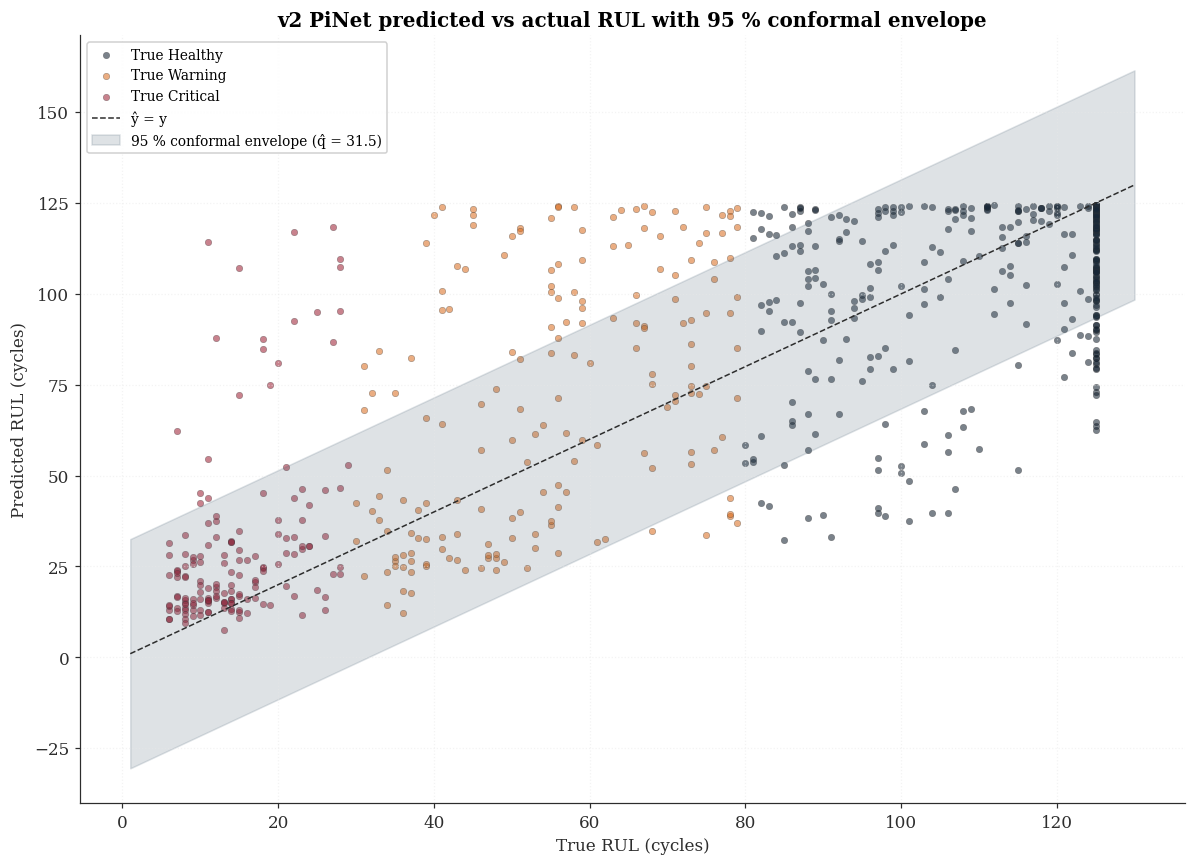

In [13]:
# ============================================================================
# Cell 13 — Visual: Predicted vs Actual with Conformal Bands
# ============================================================================
fig, ax = plt.subplots(figsize=(11, 8))
band_colors = [FC_DARK_BLUE, FC_ORANGE, FC_DEEP_RED]
band_names  = ["Healthy","Warning","Critical"]
for c in (0,1,2):
    m = (rbt == c)
    ax.scatter(rt[m], rp[m], s=18, alpha=0.55, color=band_colors[c],
               edgecolor=FC_CHARCOAL, linewidth=0.3, label=f"True {band_names[c]}")
mn = min(rt.min(), rp.min()) - 5; mx = max(rt.max(), rp.max()) + 5
ax.plot([mn, mx], [mn, mx], color=FC_CHARCOAL, linewidth=1.0, linestyle="--", label="ŷ = y")
if conformal_q is not None:
    a_min = min(conformal_q.keys()); q_min = conformal_q[a_min]
    xs = np.linspace(mn, mx, 200)
    ax.fill_between(xs, xs - q_min, xs + q_min, color=FC_STEEL, alpha=0.18,
                    label=f"95 % conformal envelope (q̂ = {q_min:.1f})")
ax.set_xlabel("True RUL (cycles)"); ax.set_ylabel("Predicted RUL (cycles)")
ax.set_title("v2 PiNet predicted vs actual RUL with 95 % conformal envelope")
ax.legend(loc="upper left"); ax.grid(linestyle=":", alpha=0.5)
plt.tight_layout()
plt.savefig(V2_OUT / "phase_v2_3_predicted_vs_actual_with_intervals.png", dpi=300, bbox_inches="tight")
plt.show()

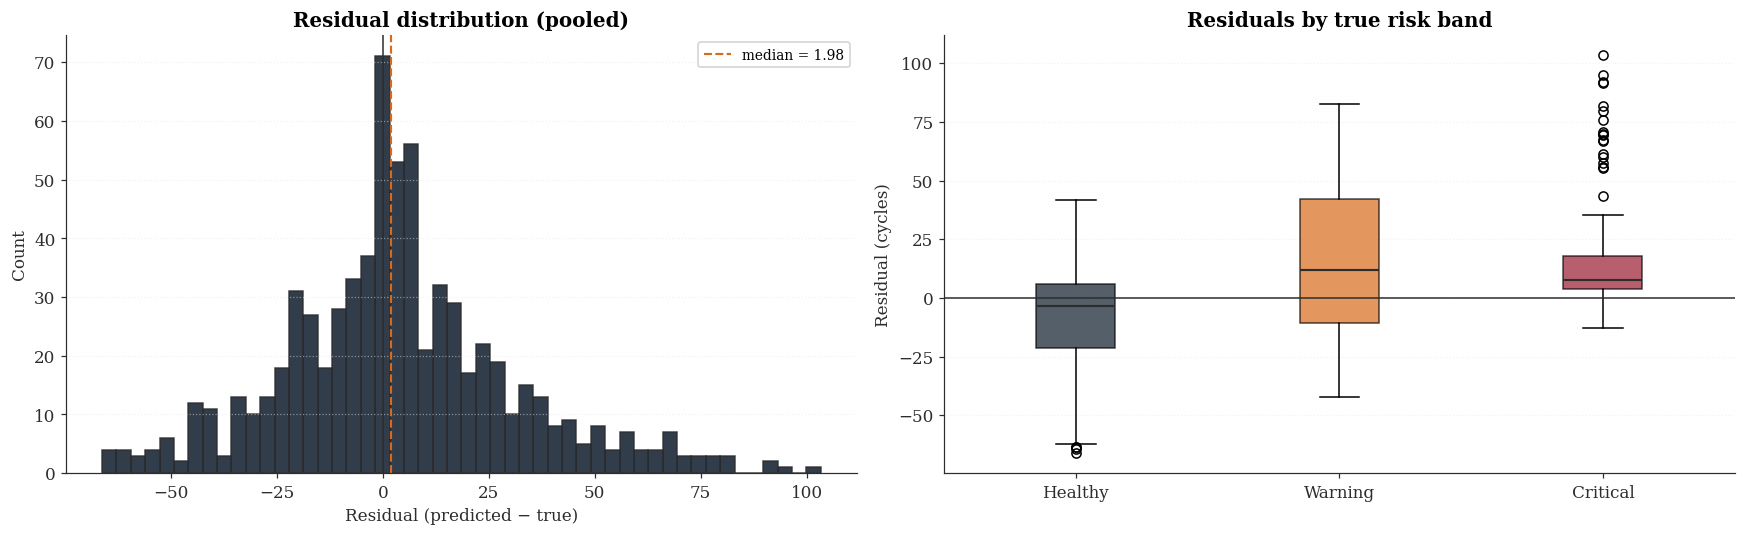

In [14]:
# ============================================================================
# Cell 14 — Visual: Residual Distribution
# ============================================================================
residuals = rp - rt
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].hist(residuals, bins=50, color=FC_DARK_BLUE, alpha=0.85, edgecolor=FC_CHARCOAL)
axes[0].axvline(0, color=FC_CHARCOAL, linewidth=1.0)
axes[0].axvline(np.median(residuals), color=FC_ORANGE, linewidth=1.4, linestyle="--",
                label=f"median = {np.median(residuals):.2f}")
axes[0].set_title("Residual distribution (pooled)")
axes[0].set_xlabel("Residual (predicted − true)")
axes[0].set_ylabel("Count")
axes[0].legend(); axes[0].grid(axis="y", linestyle=":", alpha=0.5)

data = [residuals[rbt==c] for c in (0,1,2)]
bp = axes[1].boxplot(data, labels=band_names, patch_artist=True,
                     medianprops={"color":FC_CHARCOAL, "linewidth":1.4})
for patch, col in zip(bp["boxes"], band_colors):
    patch.set_facecolor(col); patch.set_alpha(0.7)
axes[1].axhline(0, color=FC_CHARCOAL, linewidth=1.0)
axes[1].set_title("Residuals by true risk band")
axes[1].set_ylabel("Residual (cycles)")
axes[1].grid(axis="y", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.savefig(V2_OUT / "phase_v2_3_residuals.png", dpi=300, bbox_inches="tight")
plt.show()

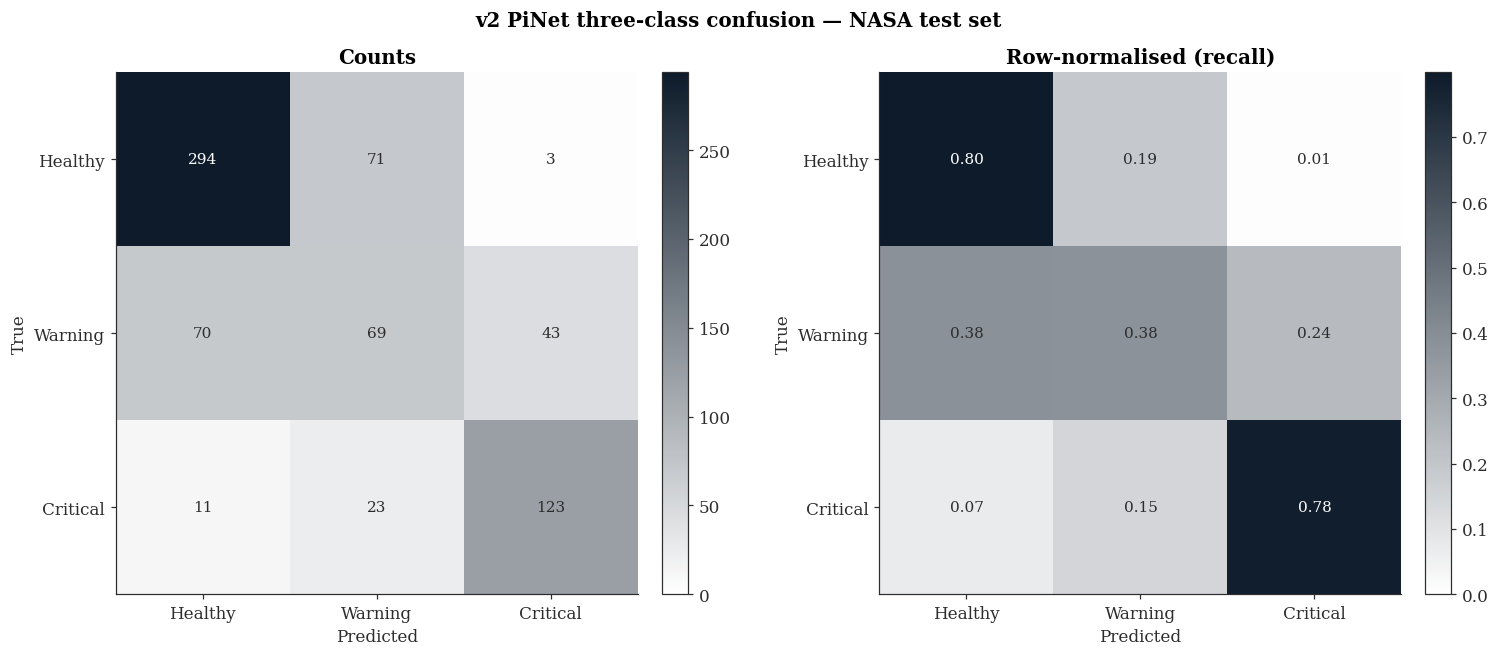

In [15]:
# ============================================================================
# Cell 15 — Visual: Three-Class Confusion Matrix
# ============================================================================
cm = confusion_matrix(rbt, rbp, labels=[0,1,2])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
nav_cmap = LinearSegmentedColormap.from_list("nav", ["#FFFFFF", FC_DARK_BLUE])
for ax, mat, title in [(axes[0], cm, "Counts"),
                       (axes[1], cm_norm, "Row-normalised (recall)")]:
    im = ax.imshow(mat, cmap=nav_cmap, aspect="equal", vmin=0,
                   vmax=mat.max() if mat.max() > 0 else 1)
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels(band_names); ax.set_yticklabels(band_names)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(title)
    for i in range(3):
        for j in range(3):
            v = mat[i,j]
            txt = f"{int(v):d}" if mat is cm else f"{v:.2f}"
            colour = "white" if v > mat.max()/2 else FC_CHARCOAL
            ax.text(j, i, txt, ha="center", va="center", color=colour, fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.suptitle("v2 PiNet three-class confusion — NASA test set", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(V2_OUT / "phase_v2_3_confusion.png", dpi=300, bbox_inches="tight")
plt.show()

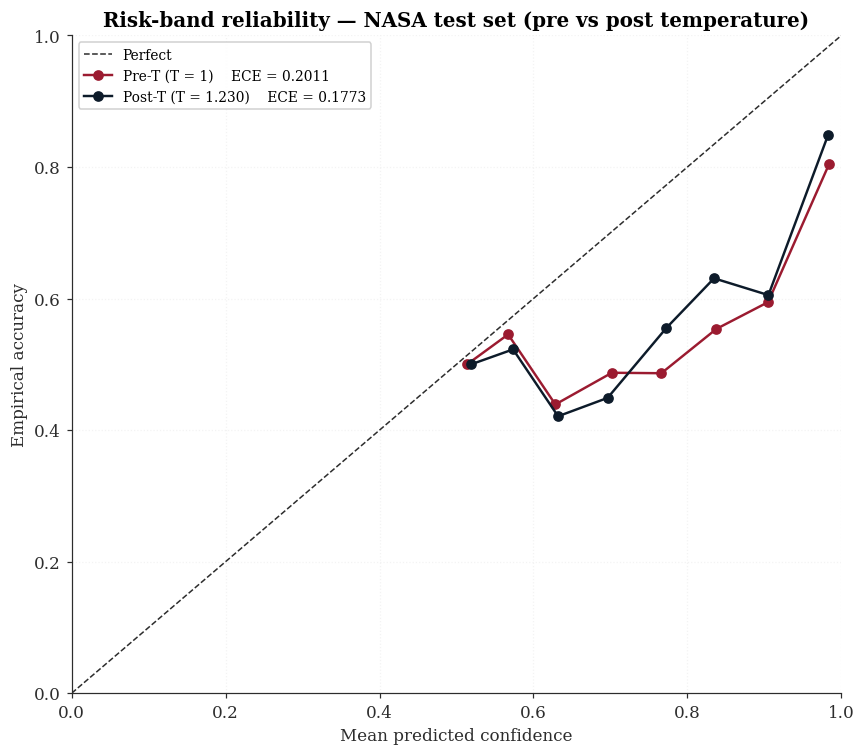

In [16]:
# ============================================================================
# Cell 16 — Visual: Reliability Diagram on Test
# ============================================================================
def reliability_bins(probs, labels, n_bins=15):
    conf = probs.max(axis=1); pred = probs.argmax(axis=1)
    correct = (pred == labels).astype(float)
    bins = np.linspace(0, 1, n_bins+1)
    centres, accs, confs = [], [], []
    for i in range(n_bins):
        m = (conf > bins[i]) & (conf <= bins[i+1])
        if m.sum() == 0: continue
        centres.append((bins[i]+bins[i+1])/2)
        accs.append(correct[m].mean())
        confs.append(conf[m].mean())
    return centres, accs, confs

c_pre,  a_pre,  conf_pre  = reliability_bins(probs_test_pre,  rbt)
c_post, a_post, conf_post = reliability_bins(probs_test_post, rbt)

fig, ax = plt.subplots(figsize=(8, 7))
ax.plot([0,1], [0,1], color=FC_CHARCOAL, linewidth=1.0, linestyle="--", label="Perfect")
ax.plot(conf_pre, a_pre,   color=FC_DEEP_RED,  linewidth=1.6, marker="o",
        label=f"Pre-T (T = 1)    ECE = {ece_pre:.4f}")
ax.plot(conf_post, a_post, color=FC_DARK_BLUE, linewidth=1.6, marker="o",
        label=f"Post-T (T = {T_value:.3f})    ECE = {ece_post:.4f}")
ax.set_xlim(0,1); ax.set_ylim(0,1)
ax.set_xlabel("Mean predicted confidence")
ax.set_ylabel("Empirical accuracy")
ax.set_title("Risk-band reliability — NASA test set (pre vs post temperature)")
ax.legend(); ax.grid(linestyle=":", alpha=0.5)
plt.tight_layout()
plt.savefig(V2_OUT / "phase_v2_3_reliability_diagram_test.png", dpi=300, bbox_inches="tight")
plt.show()

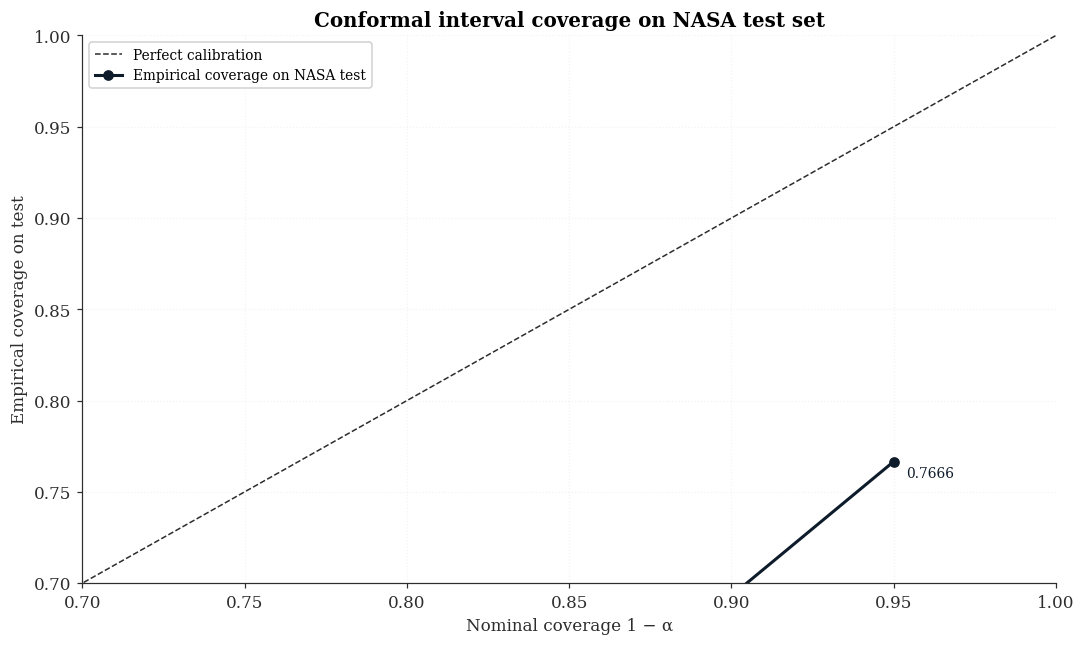

In [17]:
# ============================================================================
# Cell 17 — Visual: Coverage by α
# ============================================================================
if conformal_q is not None:
    alphas = sorted(conformal_q.keys())
    nominals = [1-a for a in alphas]
    cov_obs  = [coverage_test[a] for a in alphas]
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot([0,1], [0,1], color=FC_CHARCOAL, linestyle="--", linewidth=1.0,
            label="Perfect calibration")
    ax.plot(nominals, cov_obs, color=FC_DARK_BLUE, linewidth=2.0, marker="o",
            label="Empirical coverage on NASA test")
    for n, c in zip(nominals, cov_obs):
        ax.annotate(f"{c:.4f}", (n, c), textcoords="offset points",
                    xytext=(8, -10), fontsize=9, color=FC_DARK_BLUE)
    ax.set_xlabel("Nominal coverage 1 − α")
    ax.set_ylabel("Empirical coverage on test")
    ax.set_xlim(0.7, 1.0); ax.set_ylim(0.7, 1.0)
    ax.set_title("Conformal interval coverage on NASA test set")
    ax.legend(); ax.grid(linestyle=":", alpha=0.5)
    plt.tight_layout()
    plt.savefig(V2_OUT / "phase_v2_3_coverage_by_alpha.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Conformal artefact missing — coverage plot skipped.")

---

## Part F — Persist Headline Metrics

In [18]:
# ============================================================================
# Cell 18 — Persist Headline Metrics JSON
# ============================================================================
headline = {
    "smoke_mode":        SMOKE_MODE,
    "pinet_provenance":  provenance,
    "temperature":       T_value,
    "conformal_alphas":  list(conformal_q.keys()) if conformal_q else None,
    "v0_baseline":       {"rmse":V0_RMSE, "nasa":V0_NASA, "f2_c":V0_F2_C, "r_c":V0_R_C},
    "v1_stage_a":        {"rmse":V1A_RMSE, "nasa":V1A_NASA, "f2_c":V1A_F2_C, "r_c":V1A_R_C},
    "v2_pooled":         pooled,
    "v2_per_subset":     per_subset,
    "coverage_test":     coverage_test if conformal_q else None,
    "ece_pre":           ece_pre,
    "ece_post":          ece_post,
    "brier_pre":         br_pre,
    "brier_post":        br_post,
    "safety_gate": {
        "v0_r_c":        V0_R_C,
        "v2_r_c":        v2_R_C,
        "delta_vs_v0":   delta,
        "delta_vs_v1a":  v2_R_C - V1A_R_C,
        "outcome":       safety_outcome,
    },
}
with open(V2_OUT / "phase_v2_3_headline_metrics.json", "w") as f:
    json.dump(headline, f, indent=2)
print(f"Saved {V2_OUT / 'phase_v2_3_headline_metrics.json'}")

Saved /Users/michelemaestrini/Desktop/PiNet/FusionCore/v2/outputs/phase_v2_3_headline_metrics.json


---

## Ph-v2.3 Gate

In [19]:
# ============================================================================
# Cell 19 — Ph-v2.3 Gate
# ============================================================================
print("="*78); print("  Ph-v2.3 GATE — v2 Headline Evaluation"); print("="*78)
checks = []
checks.append(("Final-cycle prediction count = 707", len(preds) == 707, f"{len(preds)}"))
checks.append(("All test predictions finite",
               np.isfinite(rp).all() and np.isfinite(rt).all(), "all finite"))
checks.append(("Pooled RMSE recorded", np.isfinite(pooled["rmse"]), f"{pooled['rmse']:.3f}"))
checks.append(("Pooled NASA score recorded", np.isfinite(pooled["nasa"]), f"{pooled['nasa']:.1f}"))
checks.append(("Pooled Critical F2 recorded",
               np.isfinite(pooled["f2"][2]), f"{pooled['f2'][2]:.4f}"))
checks.append(("Per-subset breakdown produced",
               len(per_subset) == 4, f"{sorted(per_subset.keys())}"))
checks.append(("Safety-gate outcome recorded",
               safety_outcome in ("Strong Pass","Pass with Advisory","Fail"), safety_outcome))
if conformal_q is not None:
    for a in sorted(conformal_q.keys()):
        cov = coverage_test[a]; nominal = 1 - a
        checks.append((f"Test coverage at α = {a:.2f} within ±5% of nominal {nominal:.2f}",
                       abs(cov - nominal) <= 0.05, f"cov = {cov:.4f}"))
checks.append(("Post-T ECE on test ≤ 0.10",
               ece_post <= 0.10, f"{ece_post:.4f}"))
for fn in ("phase_v2_3_test_predictions.parquet",
           "phase_v2_3_headline_metrics.json",
           "phase_v2_3_predicted_vs_actual_with_intervals.png",
           "phase_v2_3_residuals.png",
           "phase_v2_3_confusion.png",
           "phase_v2_3_reliability_diagram_test.png"):
    checks.append((f"Persisted: {fn}", (V2_OUT / fn).exists(), "OK"))
if conformal_q is not None:
    checks.append(("Persisted: phase_v2_3_coverage_by_alpha.png",
                   (V2_OUT / "phase_v2_3_coverage_by_alpha.png").exists(), "OK"))
for desc, ok, detail in checks:
    flag = "PASS" if ok else "FAIL"
    print(f"  [{flag}] {desc:<60s} {detail}")
n_pass = sum(1 for _,o,_ in checks if o)
print(f"\n  Ph-v2.3 GATE: {n_pass}/{len(checks)} PASS")
if not all(o for _,o,_ in checks):
    fails = [d for d, o, _ in checks if not o]
    print(f"\n  FAILING checks ({len(fails)}):")
    for f in fails:
        print(f"    - {f}")
assert all(o for _,o,_ in checks), "Ph-v2.3 GATE FAILED"
print(f"\n  Safety-gate outcome: {safety_outcome}")
if SMOKE_MODE:
    print("  SMOKE MODE — re-run after Stage B (Ph-v2.0) for valid headline.")
print("  Ph-v2.3 — proceed to Ph-v2.4 (production wrapper)")

  Ph-v2.3 GATE — v2 Headline Evaluation
  [PASS] Final-cycle prediction count = 707                           707
  [PASS] All test predictions finite                                  all finite
  [PASS] Pooled RMSE recorded                                         28.053
  [PASS] Pooled NASA score recorded                                   112333.5
  [PASS] Pooled Critical F2 recorded                                  0.7716
  [PASS] Per-subset breakdown produced                                ['FD001', 'FD002', 'FD003', 'FD004']
  [PASS] Safety-gate outcome recorded                                 Fail
  [FAIL] Test coverage at α = 0.05 within ±5% of nominal 0.95         cov = 0.7666
  [FAIL] Test coverage at α = 0.10 within ±5% of nominal 0.90         cov = 0.6931
  [FAIL] Test coverage at α = 0.20 within ±5% of nominal 0.80         cov = 0.5672
  [FAIL] Post-T ECE on test ≤ 0.10                                    0.1773
  [PASS] Persisted: phase_v2_3_test_predictions.parquet         

AssertionError: Ph-v2.3 GATE FAILED

---

## Summary

### Ph-v2.3 outputs
- `phase_v2_3_test_predictions.parquet`
- `phase_v2_3_headline_metrics.json`
- six diagnostic PNGs

### Decision
The safety-gate outcome (Strong Pass / Pass with Advisory / Fail) is the
final determinant of whether v2 supersedes v1 and v0 XGBoost. Either way,
the result is recorded faithfully — nulls are publishable findings.

### Next notebook
`05_Production_Inference.ipynb` — wrap the calibrated stack in
`FusionCorePredictor` and emit the deployable artefact.